# Модели рекомендаций

Три подхода к предсказанию оценок: baseline (средний рейтинг фильма), SVD (матричная факторизация) и NCF (нейросеть на PyTorch).

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import TruncatedSVD
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Загрузка split'а из базы

Повторяем запрос из первого ноутбука, чтобы получить train и test автономно.

In [16]:
conn = sqlite3.connect('../data/movielens.db')

data_split = pd.read_sql_query("""
WITH ranked AS (
    SELECT 
        user_id, 
        item_id, 
        rating,
        timestamp, 
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp) AS rn, 
        COUNT(*) OVER (PARTITION BY user_id) AS total
    FROM ratings
)
SELECT 
    user_id, 
    item_id, 
    rating,
    CASE 
        WHEN rn<=0.8 * total THEN "train"
        ELSE "test"
    END AS split
FROM ranked
""", conn)

train = data_split[data_split['split']=="train"]
test = data_split[data_split['split']=="test"]

print(train.shape)
print(test.shape)

(79619, 4)
(20381, 4)


## 1. Baseline — средний рейтинг фильма

Простейшая модель: предсказываем каждому пользователю средний рейтинг фильма по обучающей выборке. Если фильма нет в train — используем общий средний рейтинг.

In [17]:
item_means = train.groupby("item_id")["rating"].mean()
global_mean = train['rating'].mean()

test = test.copy()
test['pred'] = test['item_id'].map(item_means).fillna(global_mean)

rmse = mean_squared_error(test['rating'], test['pred'])**0.5
print(f"Baseline RMSE: {rmse}")

Baseline RMSE: 1.0741542229315486


## 2. SVD — матричная факторизация

Строим матрицу "пользователи × фильмы", где в ячейках — оценки. Матрица сильно разреженная (~94% пропусков).

In [18]:
matrix = train.pivot_table(
    index='user_id',
    columns='item_id', 
    values='rating' 
)

print(matrix.shape)
print(f"доля заполненных ячеек: {matrix.notna().sum().sum() / matrix.size:.4f}")

(943, 1613)
доля заполненных ячеек: 0.0523


### Заполнение пропусков и центрирование

TruncatedSVD не работает с NaN. Заполняем пропуски средним рейтингом каждого фильма, затем вычитаем общий средний — так ноль означает "средний фильм".

In [19]:
matrix_filled = matrix.copy()

for item_id in matrix_filled.columns:
    if item_id in item_means.index:
        matrix_filled[item_id] = matrix_filled[item_id].fillna(item_means[item_id])
    else:
        matrix_filled[item_id] = matrix_filled[item_id].fillna(global_mean)

matrix_center = matrix_filled - global_mean

test = test.drop(columns=['pred'], errors='ignore')

## 3. Перебор параметра k

Обучаем SVD с разными значениями n_components. Чем больше k — тем сложнее модель (риск переобучения), чем меньше — риск недообучения.

In [20]:
for k in [10, 20, 50, 100]:
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(matrix_center)
    V = svd.components_
    
    matrix_pred = U @ V + global_mean
    matrix_pred_df = pd.DataFrame(matrix_pred, index=matrix_center.index, columns=matrix_center.columns)
    
    pred_long = matrix_pred_df.stack().reset_index()
    pred_long.columns = ['user_id', 'item_id', 'pred']
    
    test_pred = test.merge(pred_long, on=['user_id', 'item_id'], how='inner')
    
    rmse = mean_squared_error(test_pred['rating'], test_pred['pred']) ** 0.5
    print(f"k={k}: RMSE = {rmse:.4f}")

k=10: RMSE = 1.0371
k=20: RMSE = 1.0386
k=50: RMSE = 1.0465
k=100: RMSE = 1.0566


### Лучший SVD

Сохраняем модель с лучшим k=10 (RMSE = 1.0371).

In [21]:
svd_best = TruncatedSVD(n_components=10, random_state=42)

U_best = svd_best.fit_transform(matrix_center)
V_best = svd_best.components_
matrix_pred_best = U_best @ V_best + global_mean
matrix_pred_best_df = pd.DataFrame(matrix_pred_best, index=matrix_center.index, columns=matrix_center.columns)

## 4. Neural Collaborative Filtering (PyTorch)

Заменяем скалярное произведение SVD на нейросеть. Каждый пользователь и фильм — это обучаемый embedding длиной 32. Embeddings склеиваются и проходят через MLP: 64 → 32 → 1.

In [22]:
class NCF(nn.Module):
    def __init__(self, num_users, num_item, embedding_dim):
        super().__init__()

        self.user_embedding = nn.Embedding(num_embeddings=num_users, embedding_dim=embedding_dim)
        self.item_embedding = nn.Embedding(num_embeddings=num_item, embedding_dim=embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * embedding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)

        x = torch.cat([user_emb, item_emb], dim=1)
        x = self.mlp(x).squeeze()

        return x

### Подготовка тензоров

ID в датасете начинаются с 1, а nn.Embedding ждёт индексы от 0. Вычитаем 1 из всех user_id и item_id. ID — long, оценки — float32.

In [23]:
train_users = train['user_id'] - 1
train_items = train['item_id'] - 1
train_ratings = train['rating']
train_users_tensor = torch.tensor(train_users.values, dtype=torch.long)
train_items_tensor = torch.tensor(train_items.values, dtype=torch.long)
train_ratings_tensor = torch.tensor(train_ratings.values, dtype=torch.float32)

test_users = test['user_id'] - 1
test_items = test['item_id'] - 1
test_ratings = test['rating']
test_users_tensor = torch.tensor(test_users.values, dtype=torch.long)
test_items_tensor = torch.tensor(test_items.values, dtype=torch.long)
test_ratings_tensor = torch.tensor(test_ratings.values, dtype=torch.float32)

### Dataset и DataLoader

Оборачиваем тензоры в Dataset, делим на батчи по 1024. Train перемешивается, test — нет.

In [24]:
class RatingsDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users = users
        self.items = items
        self.ratings = ratings
        super().__init__()
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, index):
        return (self.users[index], self.items[index], self.ratings[index])


train_dataset = RatingsDataset(train_users_tensor, train_items_tensor, train_ratings_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

test_dataset = RatingsDataset(test_users_tensor, test_items_tensor, test_ratings_tensor)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

### Loss и оптимизатор

MSE для регрессии, Adam с learning_rate=0.001.

In [25]:
torch.manual_seed(42)

model = NCF(943, 1682, 32)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 5. Обучение

12 эпох: forward → loss → backward → step. После каждой эпохи считаем val_loss на тестовой выборке.

In [26]:
for epoch in range(12):
    model.train()
    train_loss_sum = 0.0
    val_loss = 0.0
    
    for user_b, item_b, rating_b in train_loader:
        optimizer.zero_grad()
        pred = model(user_b, item_b)
        loss = loss_fn(pred, rating_b)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item()
    
    model.eval()
    with torch.no_grad():
        for user_b, item_b, rating_b in test_loader:
            pred = model(user_b, item_b)
            loss = loss_fn(pred, rating_b)
            val_loss += loss.item()
    
    avg_train = train_loss_sum / len(train_loader)
    avg_val = val_loss / len(test_loader)
    print(f"Epoch {epoch+1}: train_loss={avg_train:.4f}, val_loss={avg_val:.4f}, rmse={(avg_val)**0.5:.4f}")

Epoch 1: train_loss=6.7209, val_loss=1.6598, rmse=1.2884
Epoch 2: train_loss=1.2842, val_loss=1.4278, rmse=1.1949
Epoch 3: train_loss=1.1635, val_loss=1.3438, rmse=1.1592
Epoch 4: train_loss=1.0847, val_loss=1.2847, rmse=1.1335
Epoch 5: train_loss=1.0276, val_loss=1.2231, rmse=1.1059
Epoch 6: train_loss=0.9845, val_loss=1.1805, rmse=1.0865
Epoch 7: train_loss=0.9511, val_loss=1.1525, rmse=1.0735
Epoch 8: train_loss=0.9251, val_loss=1.1264, rmse=1.0613
Epoch 9: train_loss=0.9036, val_loss=1.1046, rmse=1.0510
Epoch 10: train_loss=0.8866, val_loss=1.0931, rmse=1.0455
Epoch 11: train_loss=0.8715, val_loss=1.0789, rmse=1.0387
Epoch 12: train_loss=0.8597, val_loss=1.0660, rmse=1.0325


## 6. Сохранение модели

Сохраняем веса в .pth для возможности загрузить модель без переобучения.

In [27]:
torch.save(model.state_dict(), '../models/ncf_model.pth')

## 7. Сравнение моделей

Финальный график: baseline, SVD и NCF.

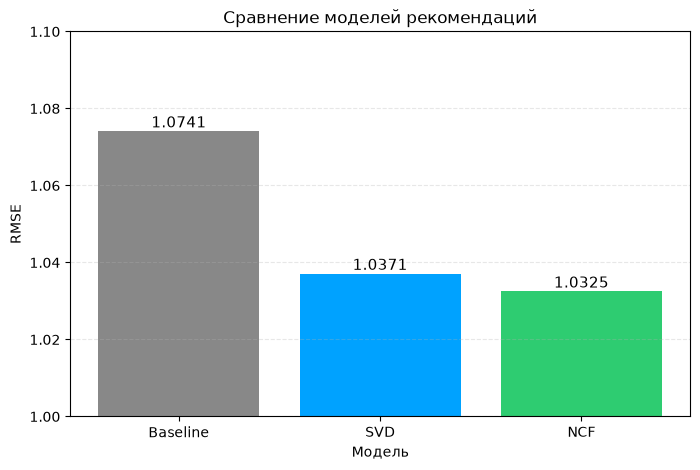

In [29]:
models = ['Baseline', 'SVD', 'NCF']
rmse_values = [1.0741, 1.0371, 1.0325]
colors = ['#888888', '#00A2FF', '#2ECC71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, rmse_values, color=colors)

for bar, v in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

ax.set_ylabel('RMSE')
ax.set_xlabel('Модель')
ax.set_title('Сравнение моделей рекомендаций')
ax.set_ylim(1.0, 1.10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig('../reports/figures/models_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

## Итоги

| Модель | RMSE |
|--------|------|
| Baseline | 1.0741 |
| SVD (k=10) | 1.0371 |
| NCF (seed=42) | 1.0325 |

NCF показал лучший результат — улучшение на 3.9% относительно baseline и на 0.4% относительно SVD. 
Разрыв между train_loss (0.86) и val_loss (1.07) указывает на переобучение: 
дальнейшее обучение не улучшает результат на тестовой выборке.